In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2


In [2]:
free = np.load('../output/example_free_tde.npz')
hf = np.load('../output/temp_free_tde.npz')
r2hf = np.load('../output/temp_rs_free_tde.npz')
sync = np.load('../output/example_tde.npz')
hs = np.load('../output/highfreq_tde.npz')

In [3]:
default_args = {}
default_args['figsize'] = (4,4)
default_args['filename_data'] = '../output/example_free_free_tde.npz'
default_args['filename_plot'] = None
default_args['stokes_q'] = False
default_args['stokes_u'] = False
default_args['stokes_v'] = False
default_args['name'] = None
default_args['frequency_num'] = None
default_args['refinement_level'] = False
default_args['width'] = None
default_args['mass'] = None
default_args['distance'] = None
default_args['axes'] = None
default_args['max_level'] = None
default_args['vmin'] = None
default_args['vmax'] = None
default_args['cmap'] = None
default_args['notex'] = False
default_args['fontsize'] = None

In [4]:
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["figure.dpi"] = 100

In [50]:
temp=(100*G*Mbh/c**2)*u.cgs.cm
print(temp)
print(temp.to(u.pc))

44298751141503.734 cm
1.4356247524763523e-05 pc


In [20]:
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit

print(T0)

2.2549164239776884e-10


In [46]:
hf = np.load('../output/r800_rayfalse_plane_correctvnr_tde1335.npz')

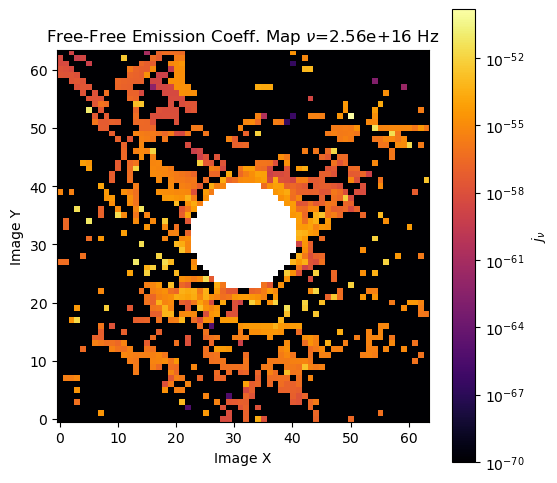

In [47]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-70
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

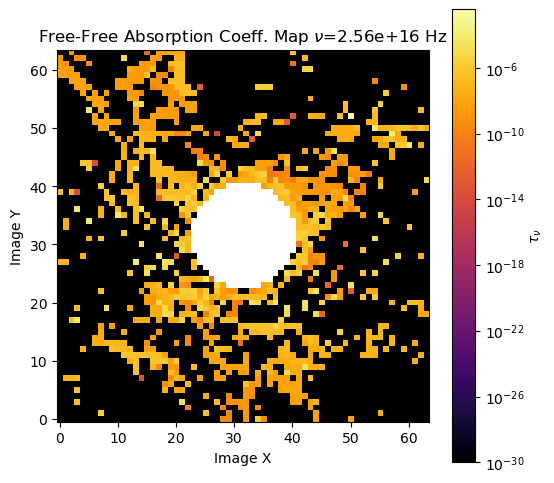

In [48]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['tau'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-30
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$\\tau_\\nu$")
plt.title('Free-Free Absorption Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

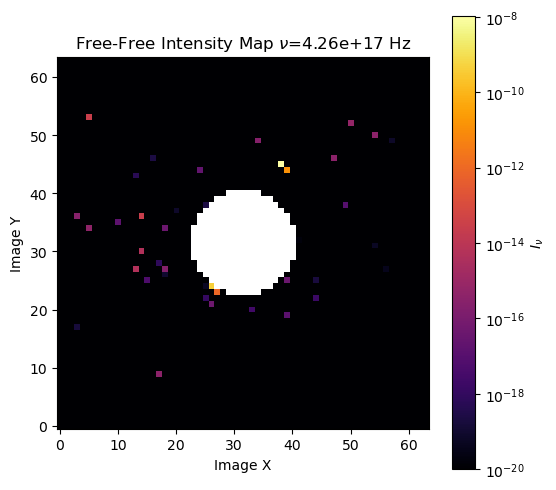

In [49]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

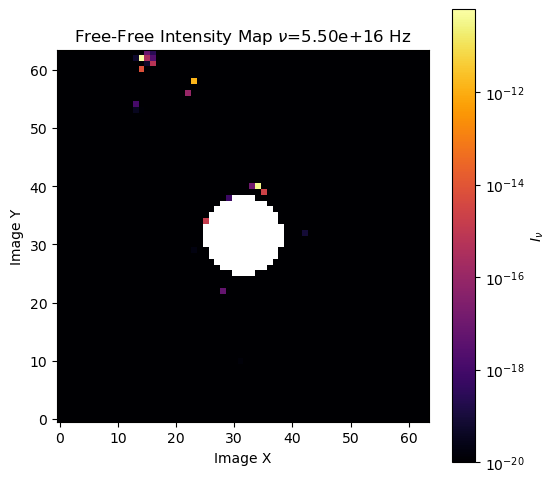

In [22]:
frequencies = np.array(hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

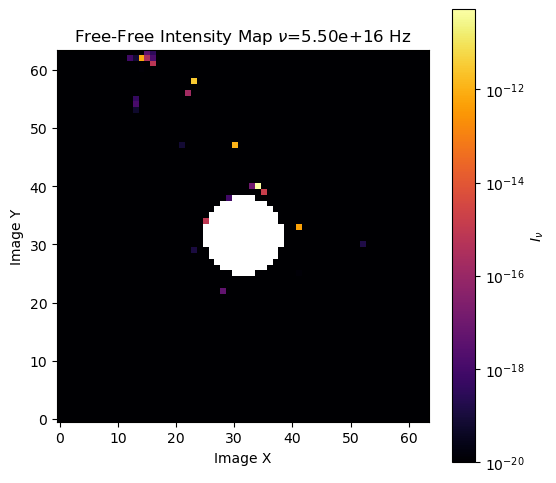

In [15]:
frequencies = np.array(r2hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(r2hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

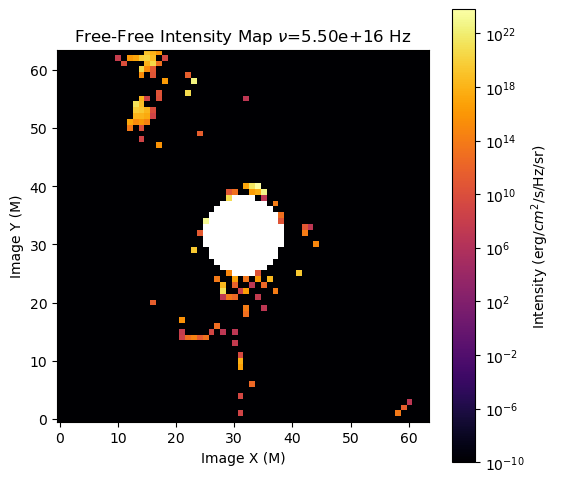

In [38]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

In [48]:
freq = len(frequencies)-3
print(np.nanmean(i))
print(np.nanmedian(i))

4.245919609251542e+21
1e-10


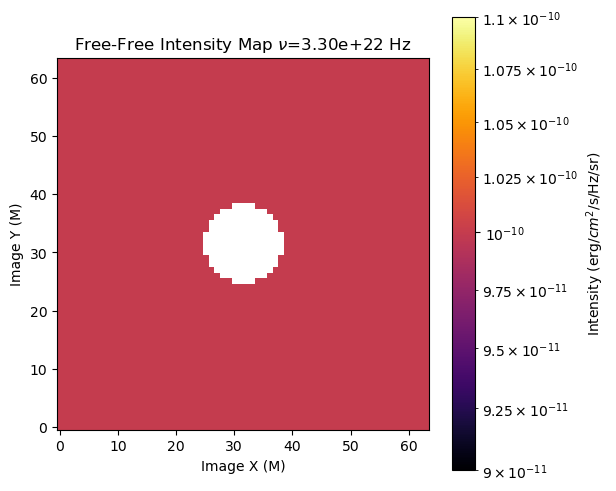

In [ ]:
freq = len(frequencies)-2
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

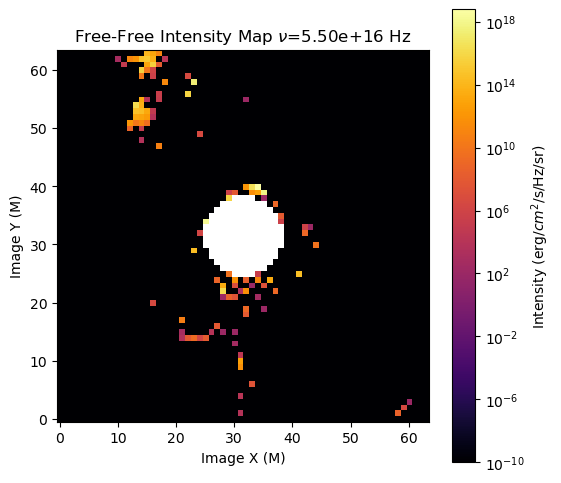

In [33]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(temp['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

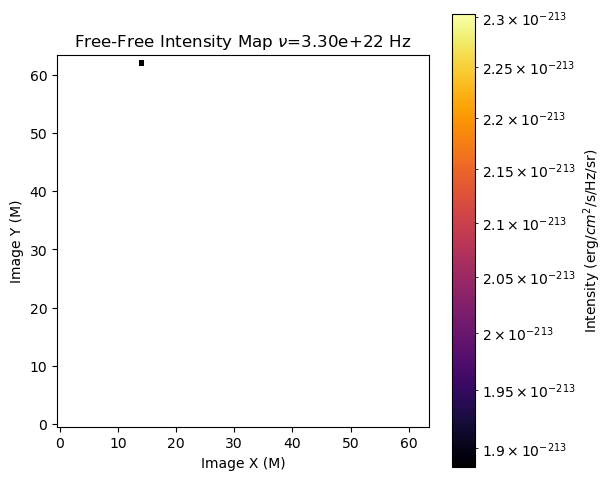

In [ ]:
for freq in range(len(frequencies)-1):
    plt.clf()
    plt.imshow(hf['I_nu'][freq],cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm())
    plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
    plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
    plt.xlabel('Image X (M)')
    plt.ylabel('Image Y (M)')
    #plt.show()
    plt.savefig('../plots/free_free_image_{0:.2e}Hz.png'.format(frequencies[freq]))

/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


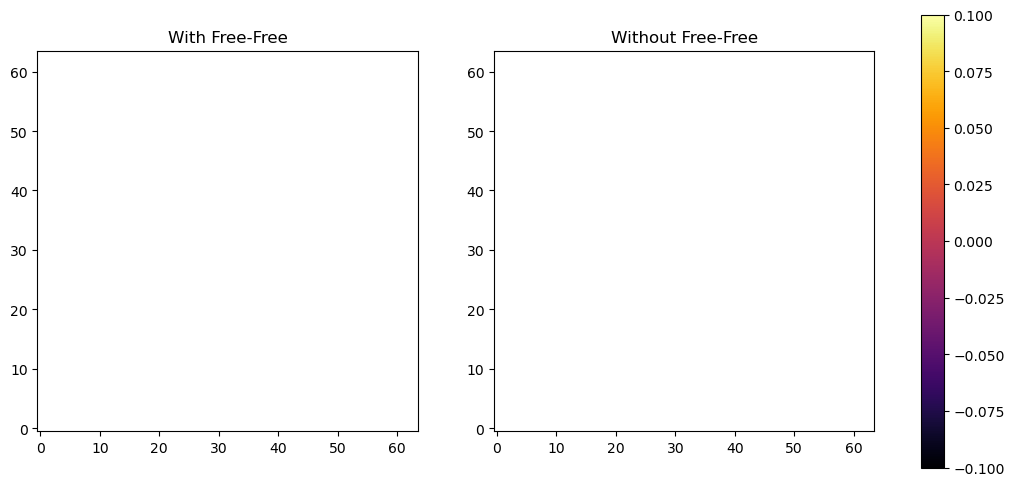

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(hf['I_nu'][15], cmap='inferno', origin='lower',vmax=1e15)
ax[1].imshow(hs['I_nu'][0], cmap='inferno', origin='lower',vmax=1e-3)
ax[0].set_title('With Free-Free')
ax[1].set_title('Without Free-Free')
plt.colorbar(ax[1].images[0], ax=ax, fraction=0.05)
plt.show()

In [24]:
free['I_nu'][32,32]

8.411915668450402e-08

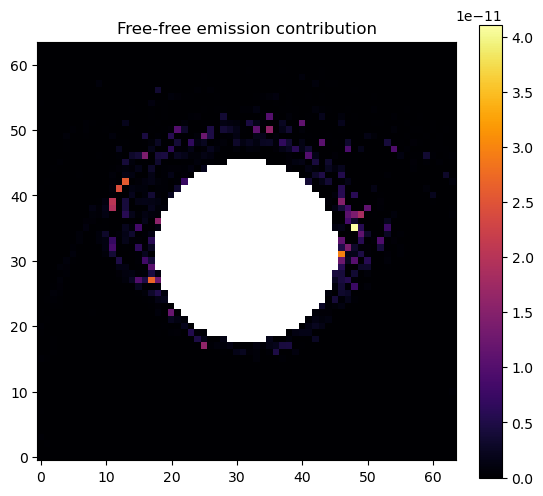

In [8]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['emission']-hs['emission'], cmap='inferno', origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Free-free emission contribution')
plt.show()

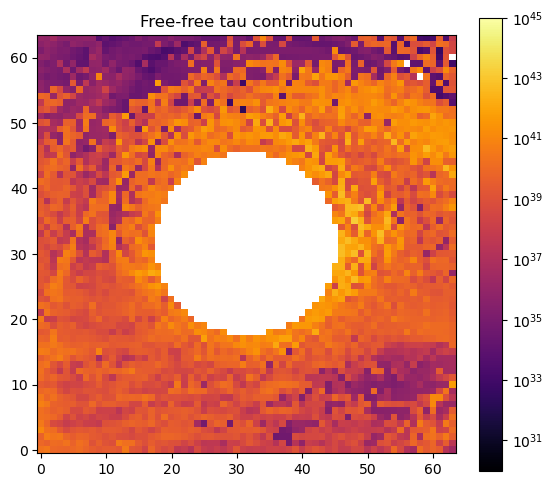

In [9]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['tau']-hs['tau'], cmap='inferno', origin='lower',norm=LogNorm(vmin=1e30, vmax=1e45))
plt.colorbar(fraction=0.05)
plt.title('Free-free tau contribution')
plt.show()

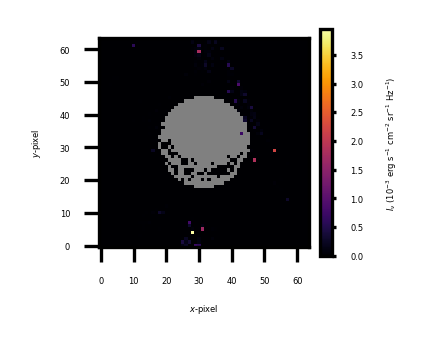

In [6]:
default_args['fontsize'] = (2)
default_args['figsize'] = (1,1)

fig,ax = utils.plot_data(**default_args)
#ax.margins(x=0,y=0)
plt.show()